In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("f1_strategy_dataset_v6.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  str    
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  str    
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  str    
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101370 non-null  float64
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife     101371 

In [37]:
df["Compound"] = df["Compound"].fillna(df["Compound"].mode()[0])
df["Prev_TyreLife"] = df["Prev_TyreLife"].fillna(0)
# we are replacing tyrelife with 0 because these are mostly of stint 1
df["Race_Orginal"] = df["Race"]
df = pd.get_dummies(df, columns = ["Compound", "Race", "Driver"], prefix = ["Compound", "Race", "Driver"], dtype = int)

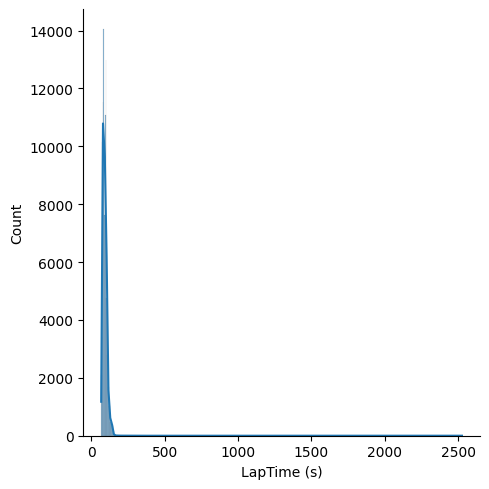

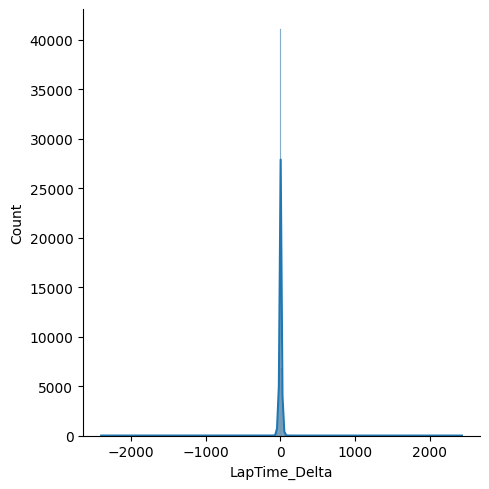

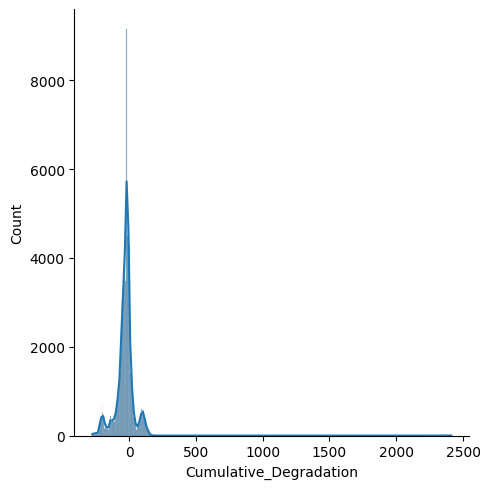

In [38]:
list = ['LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation']
for i in list:    
    sns.displot(x = i, data=df, kde = True)

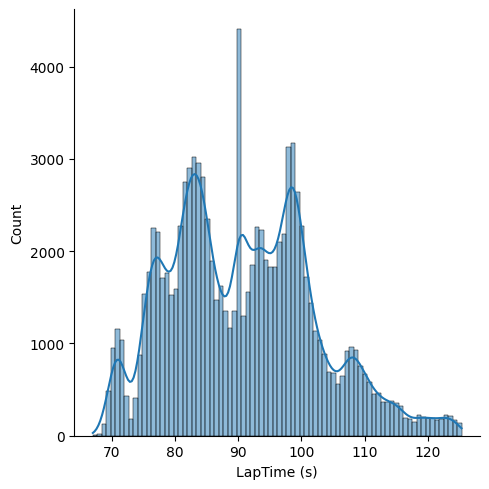

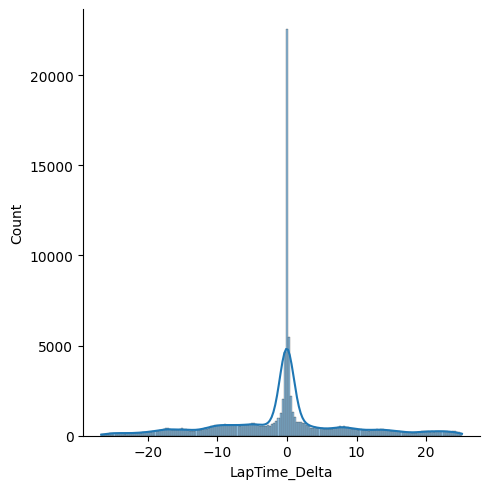

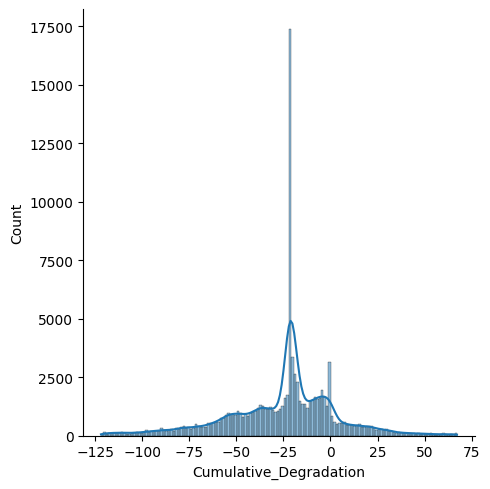

In [39]:
list = ['LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation']
for i in list:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df.loc[(df[i] < lower) | (df[i] > upper), i] = np.nan
    df[i] = df[i].fillna(df[i].median())
for i in list:    
    sns.displot(x = i, data=df, kde = True)

In [40]:
df = df.dropna(subset=['PitNextLap'])
y = df["PitNextLap"]
x = df.drop(columns = "PitNextLap")
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    stratify=df[["Race_Orginal", 'PitNextLap']],
    random_state=42
)
x_train = x_train.drop(columns = ["PitStop","Race_Orginal"])
x_test = x_test.drop(columns = ["PitStop","Race_Orginal"])

In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight={0:1, 1:8}, max_iter=1000)
lr.fit(x_train_scaled, y_train)

from sklearn.metrics import classification_report, confusion_matrix
y_pred = lr.predict(x_test_scaled)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[18884   808]
 [  316   266]]
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97     19692
         1.0       0.25      0.46      0.32       582

    accuracy                           0.94     20274
   macro avg       0.62      0.71      0.65     20274
weighted avg       0.96      0.94      0.95     20274



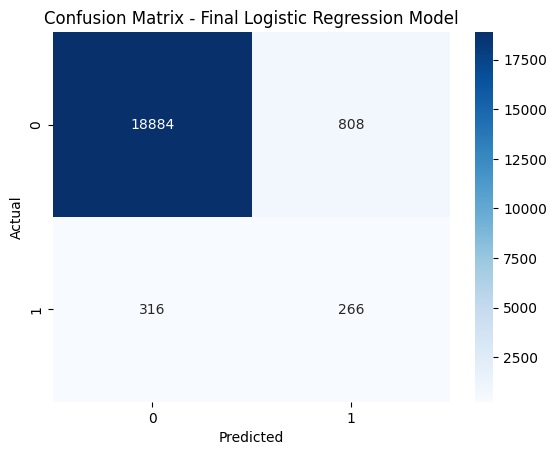

In [42]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final Logistic Regression Model')
plt.show()

In [ ]:
sample = x_test.iloc[[0]].copy()

tyre_life = float(input("Enter Tyre Life: "))
lap_number = int(input("Enter Lap Number: "))
degradation = float(input("Enter Cumulative Degradation: "))
compound = input("Enter Compound (SOFT/MEDIUM/HARD/INTERMEDIATE/WET): ").upper()
driver = input("Enter Driver code (e.g. HAM, VER, ALB): ").upper()
race = input("Enter Race name (e.g. Monaco Grand Prix): ")

sample['TyreLife'] = tyre_life
sample['LapNumber'] = lap_number
sample['Cumulative_Degradation'] = degradation

compound_cols = []
for col in sample.columns:
    if col.startswith('Compound_'):
        compound_cols.append(col)

for col in compound_cols:
    sample[col] = 0

compound_col_name = 'Compound_' + compound
if compound_col_name in compound_cols:
    sample[compound_col_name] = 1
else:
    print("Warning:", compound, "not recognized as a valid compound.")

driver_cols = []
for col in sample.columns:
    if col.startswith('Driver_'):
        driver_cols.append(col)

for col in driver_cols:
    sample[col] = 0

driver_col_name = 'Driver_' + driver
if driver_col_name in driver_cols:
    sample[driver_col_name] = 1
else:
    print("Warning:", driver, "not recognized as a valid driver.")

race_cols = []
for col in sample.columns:
    if col.startswith('Race_'):
        race_cols.append(col)

for col in race_cols:
    sample[col] = 0

race_col_name = 'Race_' + race
if race_col_name in race_cols:
    sample[race_col_name] = 1
else:
    print("Warning:", race, "not recognized as a valid race.")

sample_scaled = scaler.transform(sample)
prediction = lr.predict(sample_scaled)
probability = lr.predict_proba(sample_scaled)[:, 1]

print("\n--- Result ---")
print("Will pit next lap?", "YES" if prediction[0] == 1 else "NO")
print("Confidence:", round(probability[0] * 100, 2), "%")

Enter Tyre Life:  21
Enter Lap Number:  21


In [ ]:
df.to_csv("new_f1_csv.csv")